<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/03_markov_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Markov Chain anomaly detection
# Learn normal traffic state transitions, flag low-probability sequences

import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

In [2]:
# Load data
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_combined.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('cicids2017_combined.csv')
    print(f"Loaded from upload: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2830743, 79)


In [3]:
# Preprocessing
data.columns = data.columns.str.strip()
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
data['is_attack'] = (data['Label'] != 'BENIGN').astype(int)
print(f"Preprocessed: {data.shape}")

Preprocessed: (2827876, 80)


In [8]:
# Define traffic states based on Destination Port
# Port numbers already encode the protocol/service type

def assign_state(port):
    if port == 53:
        return 'DNS'
    elif port == 80:
        return 'HTTP'
    elif port == 443:
        return 'HTTPS'
    elif port == 22:
        return 'SSH'
    elif port == 21 or port == 20:
        return 'FTP'
    elif port < 1024:
        return 'WELL_KNOWN'
    else:
        return 'EPHEMERAL'

data['state'] = data['Destination Port'].apply(assign_state)
print(f"States:\n{data['state'].value_counts()}")

States:
state
DNS           957971
EPHEMERAL     627215
HTTP          617824
HTTPS         505327
WELL_KNOWN     88889
SSH            16921
FTP            13729
Name: count, dtype: int64


In [10]:
# Build transition matrix from BENIGN traffic only
# This learns "what does normal traffic look like?"

benign_data = data[data['is_attack'] == 0]
states = sorted(data['state'].unique())
n_states = len(states)
state_to_idx = {s: i for i, s in enumerate(states)}

# Count transitions
transition_counts = np.zeros((n_states, n_states))
benign_states = benign_data['state'].values

for i in range(len(benign_states) - 1):
    current = state_to_idx[benign_states[i]]
    next_s = state_to_idx[benign_states[i + 1]]
    transition_counts[current][next_s] += 1

# Normalize to probabilities (add small epsilon to avoid zero probabilities)
epsilon = 1e-6
transition_matrix = transition_counts + epsilon
row_sums = transition_matrix.sum(axis=1, keepdims=True)
transition_matrix = transition_matrix / row_sums

print("Transition matrix (rows = from, cols = to):")
print(pd.DataFrame(transition_matrix, index=states, columns=states).round(4))

Transition matrix (rows = from, cols = to):
               DNS  EPHEMERAL     FTP    HTTP   HTTPS     SSH  WELL_KNOWN
DNS         0.7373     0.1275  0.0011  0.0367  0.0823  0.0014      0.0137
EPHEMERAL   0.2402     0.5015  0.0067  0.0475  0.1645  0.0041      0.0355
FTP         0.2027     0.5385  0.0402  0.0473  0.1200  0.0104      0.0410
HTTP        0.1474     0.0879  0.0009  0.5217  0.2160  0.0040      0.0221
HTTPS       0.1626     0.1584  0.0008  0.0955  0.5540  0.0042      0.0244
SSH         0.1018     0.1607  0.0025  0.0941  0.2290  0.3391      0.0727
WELL_KNOWN  0.2233     0.2669  0.0023  0.0713  0.1781  0.0099      0.2482


In [11]:
# Anomaly detection: score each transition by its probability
# Low probability = anomaly

all_states = data['state'].values
scores = np.zeros(len(data))

for i in range(1, len(all_states)):
    current = state_to_idx[all_states[i - 1]]
    next_s = state_to_idx[all_states[i]]
    prob = transition_matrix[current][next_s]
    scores[i] = -np.log(prob)  # Negative log probability: high = unlikely

data['anomaly_score'] = scores

In [12]:
# Set threshold and evaluate
# Use percentile of benign scores as threshold

benign_scores = data[data['is_attack'] == 0]['anomaly_score']
threshold = np.percentile(benign_scores, 95)  # Top 5% of benign = unusual

y_true = data['is_attack'].values
y_pred = (data['anomaly_score'] > threshold).astype(int)

print(f"Threshold (95th percentile of benign): {threshold:.4f}")
print(f"\nMarkov Chain Results:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Attack']))

mc_f1 = f1_score(y_true, y_pred)
print(f"Attack F1: {mc_f1:.4f}")

Threshold (95th percentile of benign): 3.0463

Markov Chain Results:
              precision    recall  f1-score   support

      Benign       0.81      0.96      0.88   2271320
      Attack       0.29      0.07      0.11    556556

    accuracy                           0.78   2827876
   macro avg       0.55      0.51      0.49   2827876
weighted avg       0.71      0.78      0.73   2827876

Attack F1: 0.1135


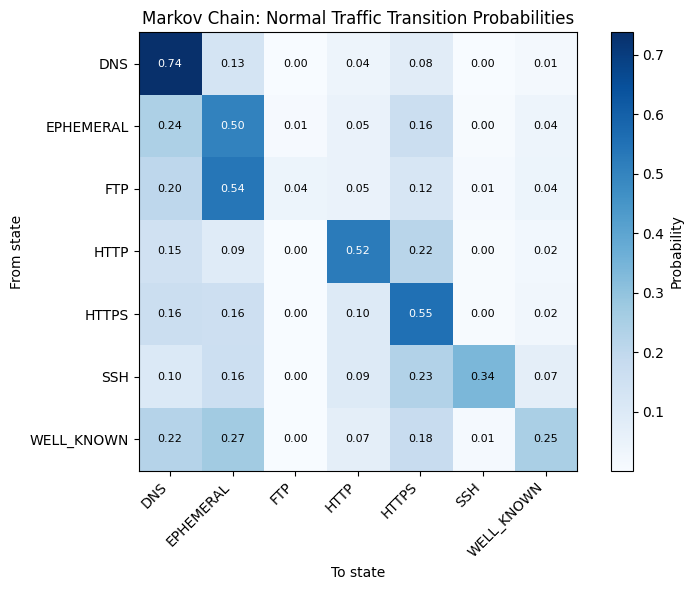

In [14]:
# Visualize transition matrix as heatmap
states = sorted(data['state'].unique())

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(transition_matrix, cmap='Blues')

ax.set_xticks(range(len(states)))
ax.set_yticks(range(len(states)))
ax.set_xticklabels(states, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(states, fontsize=10)

for i in range(len(states)):
    for j in range(len(states)):
        val = transition_matrix[i][j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_xlabel('To state')
ax.set_ylabel('From state')
ax.set_title('Markov Chain: Normal Traffic Transition Probabilities')
plt.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

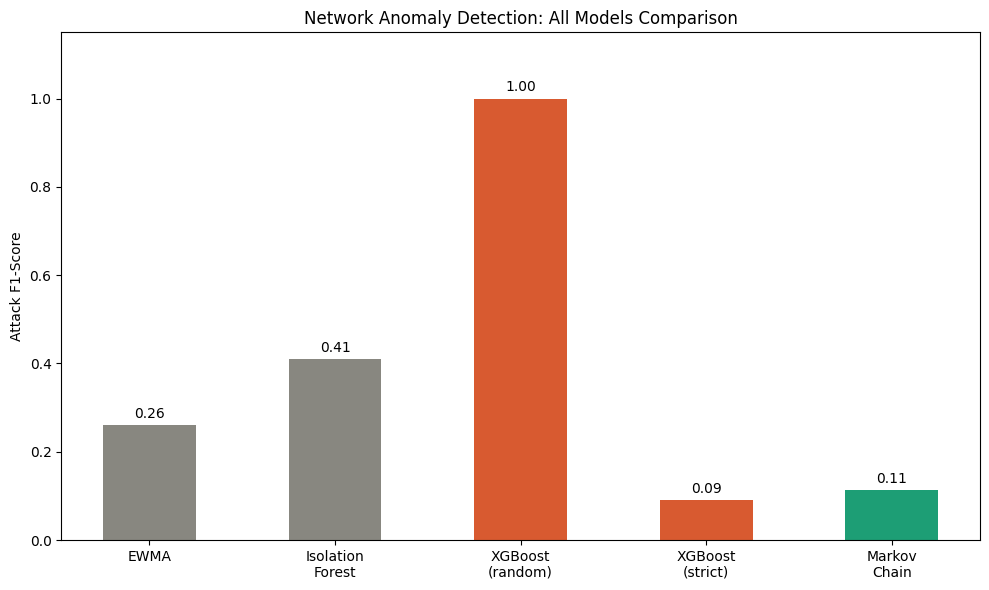

In [13]:
# Compare all Phase 1 + Phase 2 models
models = ['EWMA', 'Isolation\nForest', 'XGBoost\n(random)', 'XGBoost\n(strict)', 'Markov\nChain']
f1_scores = [0.26, 0.41, 1.00, 0.09, mc_f1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#888780', '#888780', '#D85A30', '#D85A30', '#1D9E75']
bars = ax.bar(models, f1_scores, color=colors, width=0.5)

ax.set_ylabel('Attack F1-Score')
ax.set_title('Network Anomaly Detection: All Models Comparison')
ax.set_ylim(0, 1.15)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()